In [3]:
# Hospital Healthcare Analytics
# 02 - Exploratory Analysis

print("=" * 80)
print("HOSPITAL HEALTHCARE ANALYTICS - EXPLORATORY ANALYSIS")
print("=" * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries loaded successfully.")

HOSPITAL HEALTHCARE ANALYTICS - EXPLORATORY ANALYSIS
Libraries loaded successfully.


In [4]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1]
RAW_DATA = PROJECT_ROOT / "data" / "raw"

patients = pd.read_csv(RAW_DATA / "patients.csv")
encounters = pd.read_csv(RAW_DATA / "encounters.csv")
procedures = pd.read_csv(RAW_DATA / "procedures.csv")
payers = pd.read_csv(RAW_DATA / "payers.csv")
organizations = pd.read_csv(RAW_DATA / "organizations.csv")
data_dictionary = pd.read_csv(RAW_DATA / "data_dictionary.csv")

encounters["START"] = pd.to_datetime(encounters["START"])
encounters["STOP"] = pd.to_datetime(encounters["STOP"])
procedures["START"] = pd.to_datetime(procedures["START"])
procedures["STOP"] = pd.to_datetime(procedures["STOP"])

print("Project root:", PROJECT_ROOT)
print("Data loaded successfully.")

Project root: c:\Users\Olayinka\Desktop\Data Analysis Portfolio\Hospital-patient-record
Data loaded successfully.


In [ ]:
# Display first rows and data types for key tables
print(patients.head(3))
print(patients.dtypes)

print(encounters.head(3))
print(encounters.dtypes)

print(procedures.head(3))
print(procedures.dtypes)
oatient

Basic overview

In [5]:
print("Patients:", len(patients))
print("Encounters:", len(encounters))
print("Procedures:", len(procedures))
print("Payers:", len(payers))
print("Organizations:", len(organizations))

Patients: 974
Encounters: 27891
Procedures: 47701
Payers: 10
Organizations: 1


Encounter types

In [6]:
encounter_types = (
    encounters["ENCOUNTERCLASS"]
    .value_counts()
    .reset_index()
)

encounter_types.columns = [
    "Encounter Type",
    "Count"
]

encounter_types

,Encounter Type,Count
0,ambulatory,12537
1,outpatient,6300
2,urgentcare,3666
3,emergency,2322
4,wellness,1931
5,inpatient,1135


Encounters over time

In [7]:
monthly_encounters = (
    encounters
    .assign(Month=encounters["START"].dt.to_period("M").astype(str))
    .groupby("Month")
    .size()
    .reset_index(name="Encounter Count")
)

monthly_encounters.head()

C:\Users\Olayinka\AppData\Local\Temp\ipykernel_20312\2900439734.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(Month=encounters["START"].dt.to_period("M").astype(str))


,Month,Encounter Count
0,2011-01,86
1,2011-02,86
2,2011-03,129
3,2011-04,113
4,2011-05,131


Monthly trend


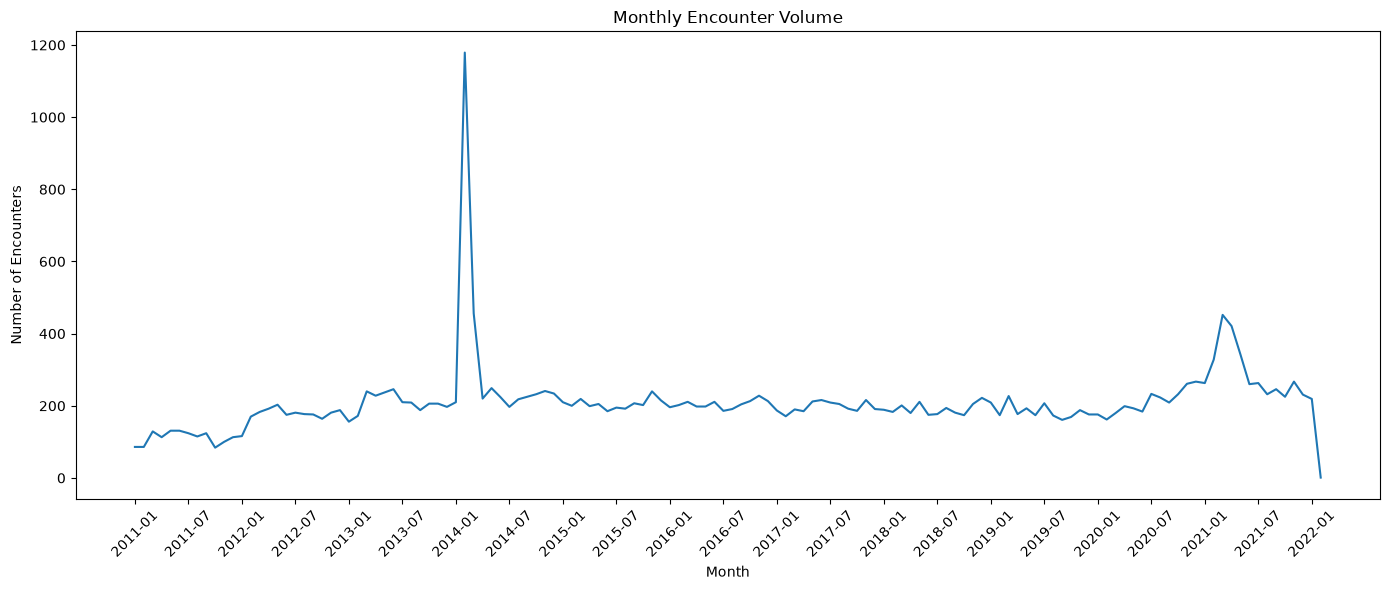

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_encounters["Month"],
    monthly_encounters["Encounter Count"]
)

plt.title("Monthly Encounter Volume")
plt.xlabel("Month")
plt.ylabel("Number of Encounters")

plt.xticks(
    range(0, len(monthly_encounters), 6),
    rotation=45
)

plt.tight_layout()
plt.show()

Claim cost analysis

In [10]:
cost_summary = encounters[
    [
        "BASE_ENCOUNTER_COST",
        "TOTAL_CLAIM_COST",
        "PAYER_COVERAGE"
    ]
].describe()

cost_summary

,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE
count,27891.000000,27891.000000,27891.000000
mean,116.181614,3639.682174,1114.965652
std,28.410082,9205.595748,4768.615576
min,85.550000,0.000000,0.000000
25%,85.550000,142.580000,0.000000
50%,136.800000,278.580000,28.440000
75%,142.580000,1412.530000,155.770000
max,146.180000,641882.700000,247751.420000


Claim cost by encounter type

In [11]:
cost_by_type = (
    encounters
    .groupby("ENCOUNTERCLASS")
    .agg(
        Encounter_Count=("Id", "count"),
        Total_Cost=("TOTAL_CLAIM_COST", "sum"),
        Average_Cost=("TOTAL_CLAIM_COST", "mean"),
        Payer_Coverage=("PAYER_COVERAGE", "sum")
    )
    .reset_index()
)

cost_by_type["Total_Cost"] = cost_by_type["Total_Cost"].round(2)
cost_by_type["Average_Cost"] = cost_by_type["Average_Cost"].round(2)
cost_by_type["Payer_Coverage"] = cost_by_type["Payer_Coverage"].round(2)

cost_by_type.sort_values(
    "Total_Cost",
    ascending=False
)

,ENCOUNTERCLASS,Encounter_Count,Total_Cost,Average_Cost,Payer_Coverage
0,ambulatory,12537,36283440.84,2894.11,12903495.75
4,urgentcare,3666,23349349.96,6369.16,3058909.73
3,outpatient,6300,14094967.12,2237.30,3777758.35
1,emergency,2322,10750051.53,4629.65,3246828.27
2,inpatient,1135,8809134.34,7761.35,3688764.95
5,wellness,1931,8227431.73,4260.71,4421749.94


Patient utilization

In [12]:
patient_utilization = (
    encounters
    .groupby("PATIENT")
    .agg(
        Encounter_Count=("Id", "count"),
        Total_Cost=("TOTAL_CLAIM_COST", "sum")
    )
    .reset_index()
)

patient_utilization.describe()

,Encounter_Count,Total_Cost
count,974.000000,9.740000e+02
mean,28.635524,1.042242e+05
std,73.035671,4.360615e+05
min,1.000000,0.000000e+00
25%,4.000000,2.583635e+03
50%,14.000000,2.414000e+04
75%,28.000000,6.075213e+04
max,1381.000000,9.932263e+06


Most frequent patients

In [13]:
patient_utilization.sort_values(
    "Encounter_Count",
    ascending=False
).head(20)

,PATIENT,Encounter_Count,Total_Cost
85,1712d26d-822d-1e3a-2267-0a9dba31d7c8,1381,2437415.31
371,5e055638-0dad-dfd5-005d-1e74b6fd29ac,887,844913.74
240,3de74169-7f67-9304-91d4-757e0f3a14d2,877,819279.19
245,3f523789-55f3-bb31-2757-4803ca6a9c2a,447,9932262.99
370,5dcb295d-92df-a147-ebcc-aa49b6262830,441,105080.78
275,442dc617-c7f2-0513-15cd-c35c4efdba73,392,156858.67
694,b4ab9ab3-f52a-751e-a990-3bd5654d5870,383,124858.48
600,9b8ae606-5059-b3a6-19c7-c812901898bb,364,187907.26
693,b4671e80-7e87-9260-ca31-6a9397d465d1,296,65245.84
973,ff331e5c-ab16-e218-f39a-63e11de1ed75,291,6356665.66


Patient utilization distribution

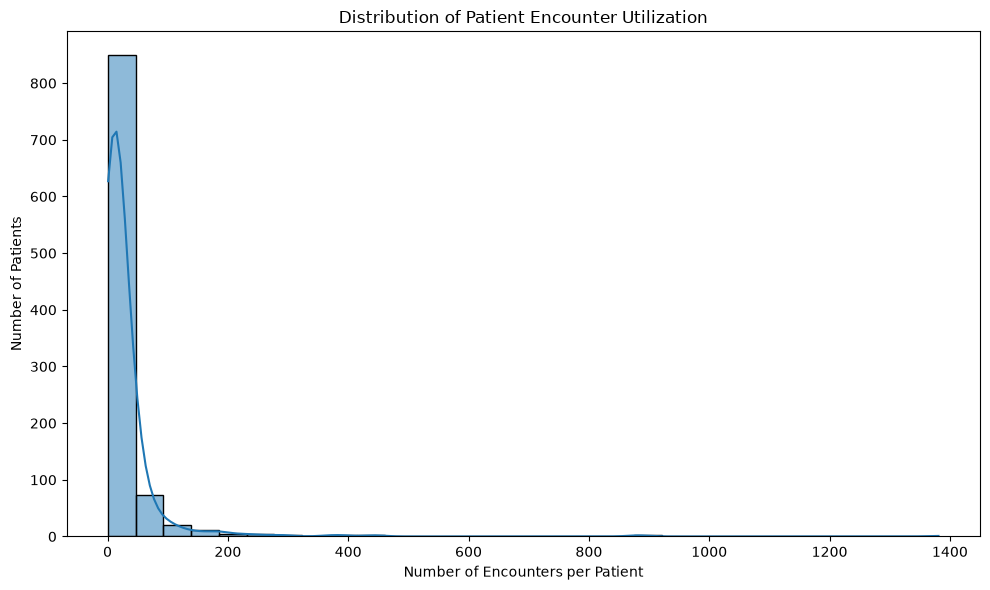

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    patient_utilization["Encounter_Count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Patient Encounter Utilization")
plt.xlabel("Number of Encounters per Patient")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

Procedure analysis

In [15]:
top_procedures = (
    procedures["DESCRIPTION"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_procedures.columns = [
    "Procedure",
    "Count"
]

top_procedures

,Procedure,Count
0,Assessment of health and social care needs (pr...,4596
1,Hospice care (regime/therapy),4098
2,Depression screening (procedure),3614
3,Depression screening using Patient Health Ques...,3614
4,Assessment of substance use (procedure),2906
5,Renal dialysis (procedure),2746
6,Assessment using Morse Fall Scale (procedure),2422
7,Assessment of anxiety (procedure),2288
8,Medication Reconciliation (procedure),2284
9,Screening for drug abuse (procedure),1484


Procedure chart

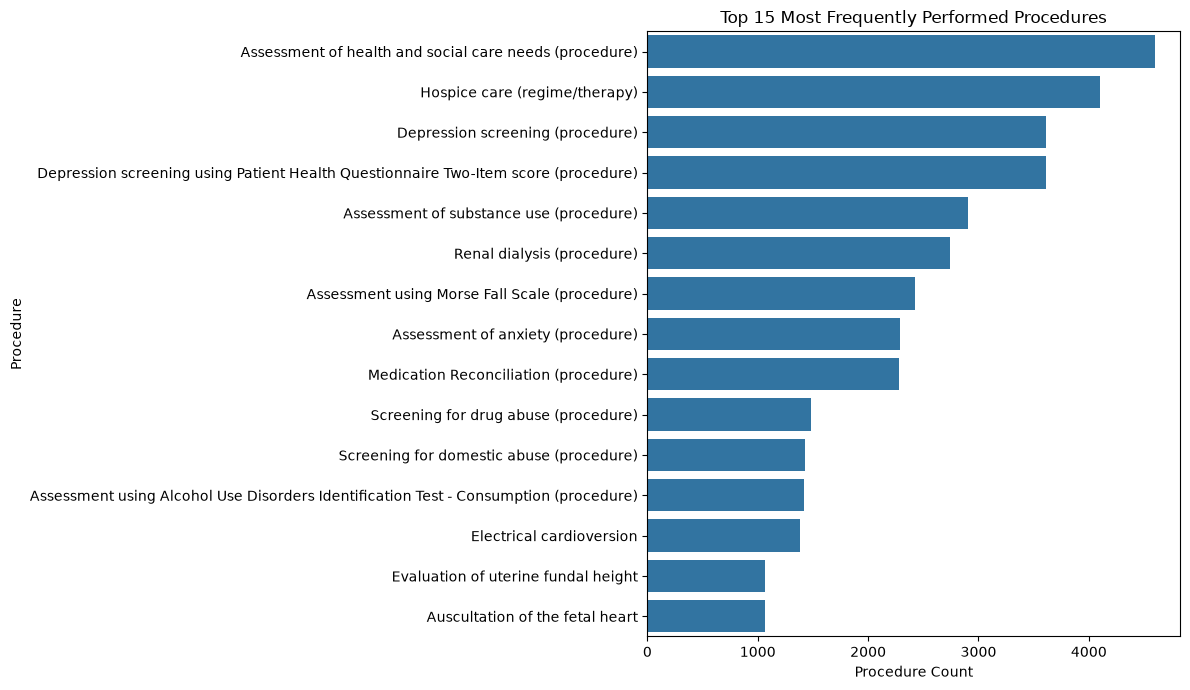

In [16]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_procedures,
    x="Count",
    y="Procedure"
)

plt.title("Top 15 Most Frequently Performed Procedures")
plt.xlabel("Procedure Count")
plt.ylabel("Procedure")
plt.tight_layout()
plt.show()

Payer analysis

In [17]:
payer_analysis = (
    encounters
    .groupby("PAYER")
    .agg(
        Encounter_Count=("Id", "count"),
        Unique_Patients=("PATIENT", "nunique"),
        Total_Claim_Cost=("TOTAL_CLAIM_COST", "sum"),
        Payer_Coverage=("PAYER_COVERAGE", "sum")
    )
    .reset_index()
)

payer_analysis["Coverage_Rate"] = (
    payer_analysis["Payer_Coverage"] /
    payer_analysis["Total_Claim_Cost"] * 100
)

payer_analysis.round(2)

,PAYER,Encounter_Count,Unique_Patients,Total_Claim_Cost,Payer_Coverage,Coverage_Rate
0,047f6ec3-6215-35eb-9608-f9dda363a44c,809,203,2424532.96,968.35,0.04
1,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,704,204,2982715.05,0.00,0.00
2,4d71f845-a6a9-3c39-b242-14d25ef86a8d,936,207,2589956.10,1780.16,0.07
3,5059a55e-5d6e-34d1-b6cb-d83d16e57bcf,900,206,2563507.98,3937.32,0.15
4,6e2f1a2d-27bd-3701-8d08-dae202c58632,925,216,3002166.01,2074496.34,69.10
5,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,1443,113,8954131.02,8417973.72,94.01
6,7caa7254-5050-3b5e-9eae-bd5ea30e809c,11371,449,24647228.89,19215691.37,77.96
7,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,8807,262,49259290.16,0.00,0.00
8,b3221cfc-24fb-339e-823d-bc4136cbc4ed,912,62,1546925.99,1380705.87,89.25
9,d47b3510-2895-3b70-9897-342d681c769d,1084,219,3543921.36,1953.86,0.06


Demographic overview

In [18]:
gender_distribution = (
    patients["GENDER"]
    .value_counts()
    .reset_index()
)

gender_distribution.columns = [
    "Gender",
    "Patient Count"
]

gender_distribution

,Gender,Patient Count
0,M,494
1,F,480


In [ ]:
# Calculate age in years for each patient
patients['Age'] = ((pd.Timestamp.today() - pd.to_datetime(patients['BIRTHDATE'])) 
                   / np.timedelta64(1, 'Y')).astype(int)

plt.figure(figsize=(10,6))
sns.histplot(patients['Age'].dropna(), bins=30, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "analysis" / "images" / "02_exploratory_analysis" / "age_distribution.png")
plt.show()


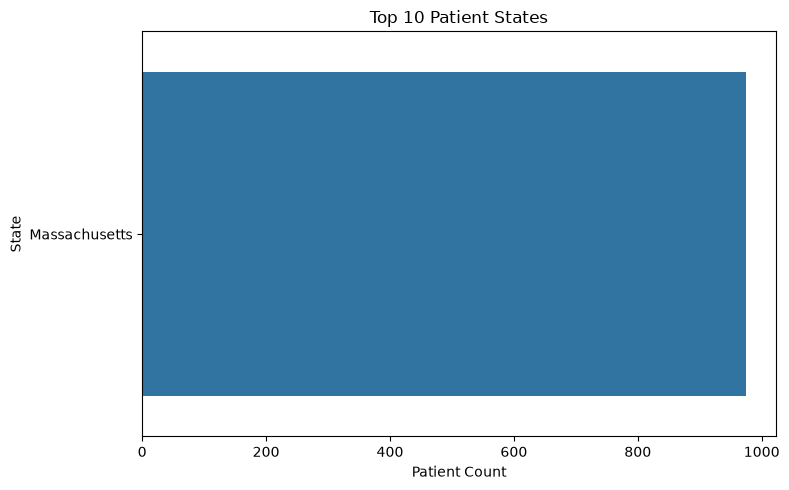

In [23]:
top_states = patients['STATE'].value_counts().head(10).reset_index()
top_states.columns = ['State','Count']
plt.figure(figsize=(8,5))
sns.barplot(data=top_states, x='Count', y='State')
plt.title("Top 10 Patient States")
plt.xlabel("Patient Count")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "images" / "02_exploratory_analysis" / "top_states.png")
plt.show()


Gender chart

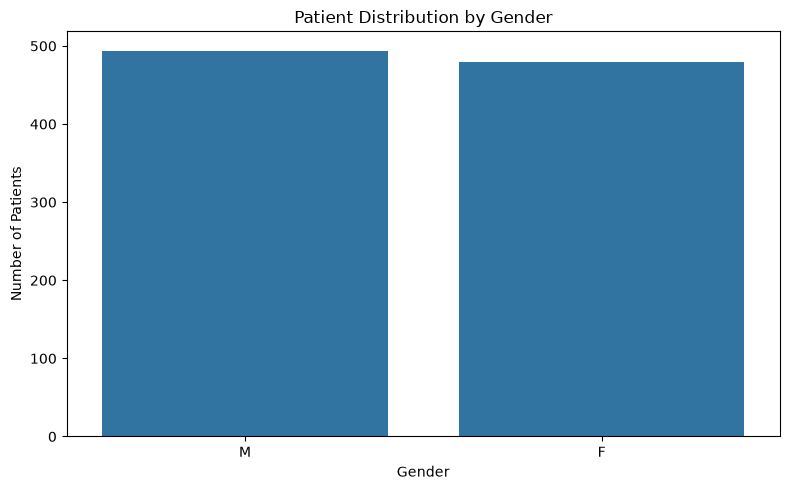

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_distribution,
    x="Gender",
    y="Patient Count"
)

plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

Race distribution

In [20]:
race_distribution = (
    patients["RACE"]
    .value_counts()
    .head(10)
    .reset_index()
)

race_distribution.columns = [
    "Race",
    "Patient Count"
]

race_distribution

,Race,Patient Count
0,white,680
1,black,163
2,asian,91
3,other,16
4,hawaiian,13
5,native,11


Final exploratory summary

In [21]:
print("""
EXPLORATORY ANALYSIS SUMMARY
============================

The exploratory analysis examined:

1. Encounter volume and encounter types.
2. Monthly healthcare utilization trends.
3. Claim cost distributions.
4. Patient-level utilization.
5. Procedure frequency.
6. Payer activity and coverage.
7. Patient demographic composition.

These findings provide the foundation for the statistical analysis
and advanced healthcare analysis stages.
""")


EXPLORATORY ANALYSIS SUMMARY

The exploratory analysis examined:

1. Encounter volume and encounter types.
2. Monthly healthcare utilization trends.
3. Claim cost distributions.
4. Patient-level utilization.
5. Procedure frequency.
6. Payer activity and coverage.
7. Patient demographic composition.

These findings provide the foundation for the statistical analysis
and advanced healthcare analysis stages.

